In [ ]:
!pip install -q transformers datasets accelerate scikit-learn
from transformers import AutoTokenizer, AutoModelForTokenClassification, TrainingArguments, Trainer, DataCollatorForTokenClassification
from datasets import Dataset
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import numpy as np
import json



# Upload Input JSON files
from google.colab import files
uploaded = files.upload()

# Load and tokenize data
model_name = "emilyalsentzer/Bio_ClinicalBERT"

label_list = ['O', 'B-ExamName', 'I-ExamName', 'E-ExamName', 'S-ExamName',
              'B-clinicaldata', 'I-clinicaldata', 'E-clinicaldata', 'S-clinicaldata',
              'B-findings', 'I-findings', 'E-findings', 'S-findings',
              'B-impression', 'I-impression', 'E-impression', 'S-impression']

label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for l, i in label2id.items()}

tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_labels(example):
    tokenized_inputs = tokenizer(
        example["tokens"],
        is_split_into_words=True,
        truncation=True,
        padding="max_length",
        max_length=256
    )
    labels = []
    word_ids = tokenized_inputs.word_ids()
    previous_word_idx = None
    for word_idx in word_ids:
        if word_idx is None:
            labels.append(-100)
        else:
            labels.append(label2id[example["labels"][word_idx]])
        previous_word_idx = word_idx
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

# Load datasets
with open("train_merged.json") as f:
    train_data = Dataset.from_list(json.load(f))

with open("test_merged.json") as f:
    test_data = Dataset.from_list(json.load(f))

train_data = train_data.map(tokenize_labels)
test_data = test_data.map(tokenize_labels)

# Load model
model = AutoModelForTokenClassification.from_pretrained(model_name, num_labels=len(label_list), id2label=id2label, label2id=label2id)

#  Set training arguments
args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=10,
    logging_dir="./logs",
    seed=42
)

#  Evaluation function
def compute_metrics(p):
    predictions, labels = p
    preds = np.argmax(predictions, axis=2)
    true_labels = [[id2label[l] for l in label if l != -100] for label in labels]
    true_preds = [[id2label[p] for (p, l) in zip(pred_row, label) if l != -100] for pred_row, label in zip(preds, labels)]
    y_true = [item for sublist in true_labels for item in sublist]
    y_pred = [item for sublist in true_preds for item in sublist]
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

#  Train
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_data,
    eval_dataset=test_data,
    tokenizer=tokenizer,
    data_collator=DataCollatorForTokenClassification(tokenizer),
    compute_metrics=compute_metrics
)

trainer.train()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 49.3 MB/s eta 0:00:00


Saving test_merged.json to test_merged.json
Saving train_merged.json to train_merged.json


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: dchintala18 (dchintala18-illinois-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.047500,0.014630,0.997066,0.997061,0.997066,0.997038
2,0.006300,0.006527,0.998948,0.998953,0.998948,0.998949
3,0.003800,0.005559,0.999107,0.999118,0.999107,0.999109


TrainOutput(global_step=594, training_loss=0.1351876309273219, metrics={'train_runtime': 210.4392, 'train_samples_per_second': 11.248, 'train_steps_per_second': 2.823, 'total_flos': 309286649534976.0, 'train_loss': 0.1351876309273219, 'epoch': 3.0})

In [ ]:
model.save_pretrained("./trained_model")
tokenizer.save_pretrained("./trained_model")


('./trained_model/tokenizer_config.json',
 './trained_model/special_tokens_map.json',
 './trained_model/vocab.txt',
 './trained_model/added_tokens.json',
 './trained_model/tokenizer.json')

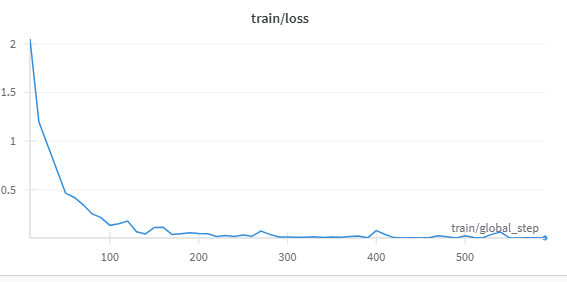

In [ ]:
final_results = trainer.predict(test_data)
print(final_results.metrics)


{'test_loss': 0.005558815784752369, 'test_accuracy': 0.9991070859110913, 'test_precision': 0.9991175773447522, 'test_recall': 0.9991070859110913, 'test_f1': 0.9991094120836311, 'test_runtime': 3.2934, 'test_samples_per_second': 60.121, 'test_steps_per_second': 15.182}


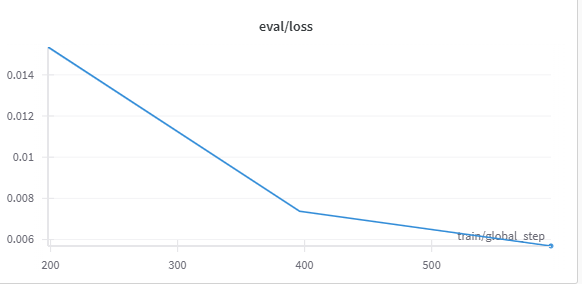

In [ ]:
from transformers import pipeline, AutoModelForTokenClassification, AutoTokenizer


model_path = "./trained_model"
model = AutoModelForTokenClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)


ner_pipeline = pipeline(
    "token-classification",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="first"
)


sentence = input("\n\n Enter ReportText to be classified :  \n\n")


results = ner_pipeline(sentence)


for entity in results:
    print(f"\n{entity['word']} → {entity['entity_group']} ({entity['score']:.4f})")


Device set to use cuda:0




 Enter ReportText to be classified :  

EXAM: CHEST RADIOGRAPHY EXAM DATE: 06/03/2021 09:48 PM. CLINICAL HISTORY: CHEST PAIN. COMPARISON: XR CHEST 2 VIEWS 12/19/2017 11:13 AM. TECHNIQUE: 1 view. FINDINGS: Lungs/Pleura: No focal opacities evident. No pleural effusion. No pneumothorax. Mediastinum: Within exam limitations, the cardiomediastinal contour is normal. Other: None. IMPRESSION: Normal single view chest. 


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



exam : chest radiography exam date : 06 / 03 / 2021 09 : 48 pm → ExamName (0.9976)

. → ExamName (0.9971)

clinical history : chest pain → clinicaldata (0.9968)

. → clinicaldata (0.9942)

comparison : xr chest 2 views 12 / 19 / 2017 11 : 13 am → ExamName (0.9986)

. → ExamName (0.9957)

technique : 1 view → ExamName (0.9973)

. → ExamName (0.9977)

findings : lungs / pleura : no focal opacities evident. no pleural effusion. no pneumothorax. mediastinum : within exam limitations, the cardiomediastinal contour is normal. other : none → findings (0.9838)

. → findings (0.9910)

impression : normal single view chest → impression (0.9980)

. → impression (0.9929)


In [ ]:

from collections import defaultdict

def merge_entities_by_group(entities):
    grouped = defaultdict(list)


    for ent in entities:
        grouped[ent["entity_group"]].append(ent)


    merged = {}
    for label, ents in grouped.items():
        ents_sorted = sorted(ents, key=lambda e: e.get("start", 0))
        merged_text = " ".join(e["word"] for e in ents_sorted)
        avg_score = sum(e["score"] for e in ents_sorted) / len(ents_sorted)
        merged[label] = (merged_text, avg_score)

    return merged

results = ner_pipeline(sentence)
merged = merge_entities_by_group(results)

for label, (text, score) in merged.items():
    print(f"{label}:\n{text} ({score:.4f})\n")


ExamName:
exam : chest radiography exam date : 06 / 03 / 2021 09 : 48 pm . comparison : xr chest 2 views 12 / 19 / 2017 11 : 13 am . technique : 1 view . (0.9973)

clinicaldata:
clinical history : chest pain . (0.9955)

findings:
findings : lungs / pleura : no focal opacities evident. no pleural effusion. no pneumothorax. mediastinum : within exam limitations, the cardiomediastinal contour is normal. other : none . (0.9874)

impression:
impression : normal single view chest . (0.9954)



In [ ]:
import pandas as pd


Results_data = [
    {"Entity": label, "Text": text, "Confidence Score": round(score, 4)}
    for label, (text, score) in merged.items()
]

df = pd.DataFrame(Results_data)
df


,Entity,Text,Confidence Score
0,ExamName,exam : chest radiography exam date : 06 / 03 /...,0.9973
1,clinicaldata,clinical history : chest pain .,0.9955
2,findings,findings : lungs / pleura : no focal opacities...,0.9874
3,impression,impression : normal single view chest .,0.9954


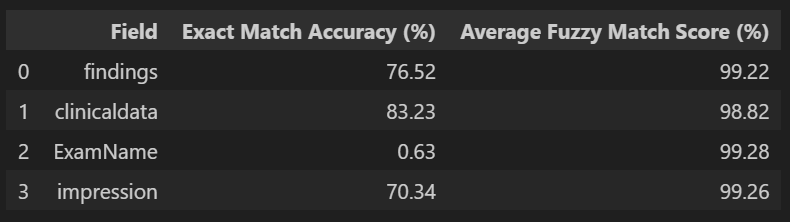

#### Token Classification of all records using fine-tunned model

In [ ]:
import pandas as pd
from transformers import pipeline, AutoModelForTokenClassification, AutoTokenizer
from collections import defaultdict
import os

# Load the data
data = pd.read_csv("open_ave_data.csv", index_col=0)

# Load the fine-tuned model
model_path = "/content/drive/My Drive/Colab Notebooks/trained_model"
model = AutoModelForTokenClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)

ner_pipeline = pipeline(
    "token-classification",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="first"
)

def merge_entities(entities):
    grouped = defaultdict(list)
    for ent in entities:
        grouped[ent["entity_group"]].append(ent)
    merged = {}
    for label, ents in grouped.items():
        ents_sorted = sorted(ents, key=lambda e: e.get("start", 0))
        merged_text = " ".join(e["word"] for e in ents_sorted)
        avg_score = sum(e["score"] for e in ents_sorted) / len(ents_sorted)
        merged[label] = merged_text.strip()
    return merged

classified_results = []
for idx, row in data.iterrows():
    report = row['ReportText']
    result = ner_pipeline(report)
    merged = merge_entities(result)
    classified_results.append(merged)

classified_df = pd.DataFrame(classified_results)
classified_df.to_csv("/content/drive/My Drive/Colab Notebooks/finetuned_classified_output.csv", index=False)


Device set to use cuda:0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Comparing with ground truth labels

In [ ]:
import pandas as pd
import re
from dateutil import parser

# Load extracted and ground truth data
extracted_df = pd.read_csv("/content/drive/My Drive/Colab Notebooks/finetuned_classified_output.csv")
ground_truth_df = pd.read_csv("/content/drive/My Drive/Colab Notebooks/ground_truth.csv")

fields = ["findings", "clinicaldata", "ExamName", "impression"]


def canonicalize_examname(text):
    if not isinstance(text, str):
        return ""
    parts = re.findall(r'(exam.*?)(comparison:.*?\.)?(technique:.*?\.)?', text)
    if parts:
        exam, comparison, technique = parts[0]
        return f"{exam}{technique or ''}{comparison or ''}".strip()
    return text




# Clean and normalize raw text
def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = text.strip()
    text = text.replace('\xa0', ' ')   # non-breaking space
    text = text.replace('\u200b', '')  # zero-width space
    text = text.lower()

    text = re.sub(r'\s*:\s*', ':', text)
    text = re.sub(r'\s*/\s*', '/', text)
    text = re.sub(r'\s*-\s*', '-', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\s*\.\s*', '.', text)

    # Remove extra spaces around brackets
    text = re.sub(r'\[\s+', '[', text)
    text = re.sub(r'\s+\]', ']', text)

    # Normalize datetime
    def normalize_datetime(match):
        try:
            dt = parser.parse(match.group())
            return dt.strftime("%m/%d/%Y %I:%M %p").lower()
        except:
            return match.group()

    text = re.sub(r'\d{2}/\d{2}/\d{4} \d{1,2}:\d{2}(?: ?[ap]m| ?[AP]M)', normalize_datetime, text)
    return text

# Apply cleaning and canonicalization
for field in fields:
    extracted_df[field] = extracted_df[field].apply(clean_text)
    ground_truth_df[field] = ground_truth_df[field].apply(clean_text)

    if field.lower() == "examname":
        extracted_df[field] = extracted_df[field].apply(canonicalize_examname)
        ground_truth_df[field] = ground_truth_df[field].apply(canonicalize_examname)



# Evaluate: exact match only
results = []
for field in fields:
    total = len(extracted_df)
    exact_matches = (extracted_df[field] == ground_truth_df[field]).sum()
    exact_accuracy = exact_matches / total * 100

    results.append({
        "Field": field,
        "Exact Match Accuracy (%)": round(exact_accuracy, 2)
    })

# Save results to CSV
evaluation_df = pd.DataFrame(results)
evaluation_df.to_csv("/content/drive/My Drive/Colab Notebooks/finetuned_exact_only.csv", index=False)


In [ ]:
import os
os.environ['METAFLOW_USER'] = 'colab_user'




## Metaflow workflow

In [ ]:
!python "/content/drive/My Drive/Colab Notebooks/nlp_metaflow.py" run


Metaflow 2.16.4 executing MedicalNLPFlow for user:colab_user
Creating local datastore in current directory (/content/drive/My Drive/Colab Notebooks/.metaflow)
Validating your flow...
    The graph looks good!
Running pylint...
    Pylint not found, so extra checks are disabled.
2025-07-17 21:45:01.495 Workflow starting (run-id 1752788701467058):
2025-07-17 21:45:02.099 [1752788701467058/start/1 (pid 54932)] Task is starting.
2025-07-17 21:45:04.816 [1752788701467058/start/1 (pid 54932)] Starting Medical NLP Flow
2025-07-17 21:45:05.467 [1752788701467058/start/1 (pid 54932)] Task finished successfully.
2025-07-17 21:45:05.559 [1752788701467058/eda/2 (pid 54957)] Task is starting.
2025-07-17 21:45:08.331 [1752788701467058/eda/2 (pid 54957)] EDA Step
2025-07-17 21:45:08.352 [1752788701467058/eda/2 (pid 54957)] Total no.of records in the dataset:  954
2025-07-17 21:45:08.353 [1752788701467058/eda/2 (pid 54957)] Total no.of columns in the dataset:  5
2025-07-17 21:45:08.354 [175278870146705

In [ ]:
import pandas as pd

results_df= pd.read_csv("/content/drive/My Drive/Colab Notebooks/results/final_metaflow_eval.csv")

pivot_df = results_df.pivot(index="Field", columns="Model", values="Exact Match Accuracy (%)").reset_index()
pivot_df.columns = ["Field", "Finetune_Exact_Match_Accuracy", "Prompt_Exact_Match_Accuracy"]
pivot_df = pivot_df[["Field", "Prompt_Exact_Match_Accuracy", "Finetune_Exact_Match_Accuracy"]]
pivot_df


,Field,Prompt_Exact_Match_Accuracy,Finetune_Exact_Match_Accuracy
0,ExamName,86.27,83.02
1,clinicaldata,84.17,96.54
2,findings,76.83,95.39
3,impression,70.75,94.97
